In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df = pd.read_csv('/content/Engage 2026 - Sheet1.csv')
df

,,age_years,sex,religion,county_residence,subcounty_residence,residence_type,year_of_study,programme_course,marital_status,...,vegetable_consumption_per_week,sugary_drink_consumption_per_week,fast_food_consumption_per_week,physical_activity_frequency_per_week,average_sleep_hours_per_night,daily_water_intake_glasses,self_reported_health_status,chronic_condition,food_allergy_intolerance,nutritional_supplements
0,1.0,22.0,Female,Christian,kiambu,Githunguri,Urban,4,Epidemiology,Single,...,7.0,0.0,0,10.0,10.0,4.0,Excellent,No,No,No
1,2.0,25.0,Female,Christian,Nyeri,Mathira,Rural,4,Education Science,Single,...,6.0,4.0,1,7.0,8.0,6.0,Good,No,No,No
2,3.0,30.0,Female,Christian,Kwale,Kwale South,Urban,6,MbChb,Married,...,17.0,5.0,7,3.0,10.0,1.5,Good,No,No,Yes
3,4.0,24.0,Female,Christian,Nakuru,Njoro,Urban,4,Medical Laboratory,single,...,7.0,1.0,3,0.0,8.0,3.0,Excellent,No,No,No
4,5.0,22.0,Female,Christian,Trans-nzoia,Kwanza,Urban,4,Education Science,Single,...,6.0,7.0,1,5.0,7.0,3.0,Good,No,No,Yes
5,6.0,22.0,Female,Christian,nakuru,lanet,Rural,4,accounting,Single,...,6.0,5.0,2,3.0,8.0,3.0,good,No,no,no
6,7.0,21.0,Female,Christian,Bomet,Konoin,Rural,4,Actuarial Science,Single,...,5.0,5.0,3,3.0,8.0,4.0,good,No,No,No
7,8.0,22.0,Female,Christian,kitui,kitui east,Rural,4,Education science,Married,...,10.0,3.0,3,7.0,9.0,8.0,good,No,No,No
8,9.0,23.0,Female,Christian,kakamega,lurambi,Rural,4,sociology,Married,...,7.0,7.0,rarely,2.0,6.0,2.0,good,no,no,no
9,10.0,24.0,Female,Christian,Makueni,kibwezi,Rural,4,BBIT,Single,...,4.0,2.0,2,7.0,5.0,6.0,good,no,no,no


### Data Overview: Types and Missing Values

In [ ]:
df.describe()

,age_years,weight_kg,height_cm,waist_circumference_cm,muac_cm,bmi,meals_per_day,fruit_consumption_per_week,vegetable_consumption_per_week,sugary_drink_consumption_per_week,physical_activity_frequency_per_week,average_sleep_hours_per_night,daily_water_intake_glasses
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,22.863636,57.545455,159.345455,28.727273,16.954545,21.985909,3.136364,3.363636,6.681818,4.181818,4.636364,7.636364,4.613636
std,2.030610,13.383456,9.644575,3.149933,5.690236,3.512960,0.560226,1.787402,2.834924,2.611994,2.421048,1.328997,1.772353
min,20.000000,41.000000,150.000000,24.000000,10.000000,18.000000,2.000000,0.000000,2.000000,0.000000,0.000000,5.000000,1.500000
25%,22.000000,52.000000,153.500000,27.250000,13.000000,19.647500,3.000000,2.250000,6.000000,2.250000,3.000000,7.000000,3.250000
50%,22.000000,55.000000,158.000000,28.000000,15.500000,21.295000,3.000000,3.000000,7.000000,4.000000,5.000000,8.000000,4.000000
75%,23.750000,60.000000,161.550000,30.000000,20.000000,23.825000,3.000000,4.000000,7.000000,6.500000,7.000000,8.000000,6.000000
max,30.000000,109.000000,192.000000,38.000000,29.000000,30.700000,5.000000,7.000000,17.000000,10.000000,10.000000,10.000000,8.000000


In [ ]:
df.dtypes


,0
age_years,float64
sex,object
religion,object
county_residence,object
subcounty_residence,object
residence_type,object
year_of_study,object
programme_course,object
marital_status,object
weight_kg,float64


### Data Cleaning: Dropping Unnamed Column and Handling Missing Values

In [ ]:
df.isna().sum()

,0
age_years,0
sex,0
religion,0
county_residence,0
subcounty_residence,0
residence_type,0
year_of_study,0
programme_course,0
marital_status,0
weight_kg,0


In [ ]:
# Identify and handle outlier in 'height_cm'
# Given the maximum height of 520 cm is an extreme outlier, we'll replace it with the median height.
median_height = df['height_cm'].median()
df.loc[df['height_cm'] > 300, 'height_cm'] = median_height
print(f"Replaced unrealistic height values (e.g., > 300 cm) in 'height_cm' with the median height: {median_height} cm")

print('\nDescriptive Statistics for Numerical Columns After Outlier Treatment:')
display(df.describe())

Replaced unrealistic height values (e.g., > 300 cm) in 'height_cm' with the median height: 158.0 cm

Descriptive Statistics for Numerical Columns After Outlier Treatment:


,age_years,weight_kg,height_cm,waist_circumference_cm,muac_cm,bmi,meals_per_day,fruit_consumption_per_week,vegetable_consumption_per_week,sugary_drink_consumption_per_week,physical_activity_frequency_per_week,average_sleep_hours_per_night,daily_water_intake_glasses
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,22.863636,57.545455,159.345455,28.727273,16.954545,21.985909,3.136364,3.363636,6.681818,4.181818,4.636364,7.636364,4.613636
std,2.030610,13.383456,9.644575,3.149933,5.690236,3.512960,0.560226,1.787402,2.834924,2.611994,2.421048,1.328997,1.772353
min,20.000000,41.000000,150.000000,24.000000,10.000000,18.000000,2.000000,0.000000,2.000000,0.000000,0.000000,5.000000,1.500000
25%,22.000000,52.000000,153.500000,27.250000,13.000000,19.647500,3.000000,2.250000,6.000000,2.250000,3.000000,7.000000,3.250000
50%,22.000000,55.000000,158.000000,28.000000,15.500000,21.295000,3.000000,3.000000,7.000000,4.000000,5.000000,8.000000,4.000000
75%,23.750000,60.000000,161.550000,30.000000,20.000000,23.825000,3.000000,4.000000,7.000000,6.500000,7.000000,8.000000,6.000000
max,30.000000,109.000000,192.000000,38.000000,29.000000,30.700000,5.000000,7.000000,17.000000,10.000000,10.000000,10.000000,8.000000


### Dropping any remaining Null Values

In [ ]:
# Drop rows with any remaining null values (should not change the DataFrame at this point)
initial_rows = df.shape[0]
df_cleaned = df.dropna()

# Report if any rows were dropped
if df_cleaned.shape[0] < initial_rows:
    print(f"{initial_rows - df_cleaned.shape[0]} rows were dropped due to null values.")
else:
    print("No additional rows with null values were found or dropped.")

# Display the count of null values after this operation to confirm
print('\nNull values after dropping:')
display(df_cleaned.isnull().sum())

No additional rows with null values were found or dropped.

Null values after dropping:


,0
age_years,0
sex,0
religion,0
county_residence,0
subcounty_residence,0
residence_type,0
year_of_study,0
programme_course,0
marital_status,0
weight_kg,0


### Feature Engineering: `bmi_category`

In [ ]:
# Define BMI categories based on standard classifications
bins = [0, 18.5, 24.9, 29.9, np.inf]
labels = ['Underweight', 'Normal weight', 'Overweight', 'Obesity']

df['bmi_category'] = pd.cut(df['bmi'], bins=bins, labels=labels, right=True)

print('Distribution of BMI categories:')
display(df['bmi_category'].value_counts())

Distribution of BMI categories:


,count
bmi_category,
Normal weight,15
Underweight,3
Overweight,3
Obesity,1


### Visualization: BMI Category Distribution

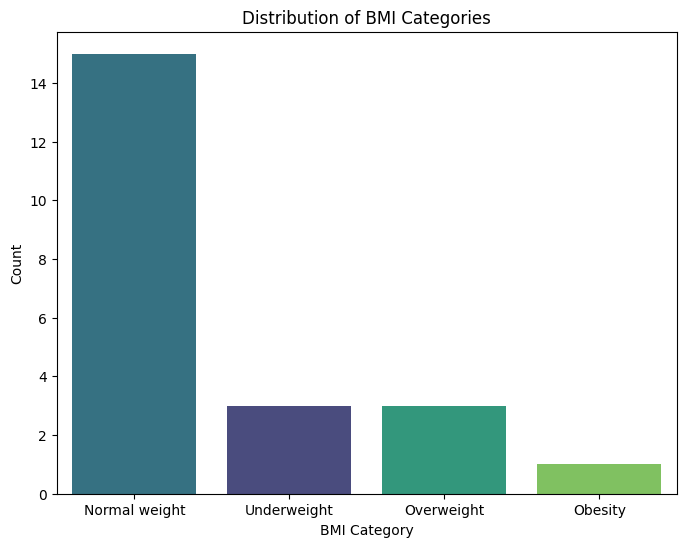

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='bmi_category', data=df, palette='viridis', hue='bmi_category', legend=False, order=df['bmi_category'].value_counts().index)
plt.title('Distribution of BMI Categories')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.show()

### Exploring `self_reported_health_status`

In [ ]:
df['self_reported_health_status'] = df['self_reported_health_status'].str.title()
print('Unique values in self_reported_health_status after standardization:')
display(df['self_reported_health_status'].value_counts())

Unique values in self_reported_health_status:


,count
self_reported_health_status,
Good,10
good,6
Excellent,3
Excellent,1
Fair,1
excellent,1


In [ ]:
df['marital_status'] = df['marital_status'].str.title()
print('Unique values in marital_status after standardization:')
display(df['marital_status'].value_counts())

Unique values in marital_status after standardization:


,count
marital_status,
Single,18
Married,3
Choose Not To Say,1


### Visualization: Marital Status Distribution

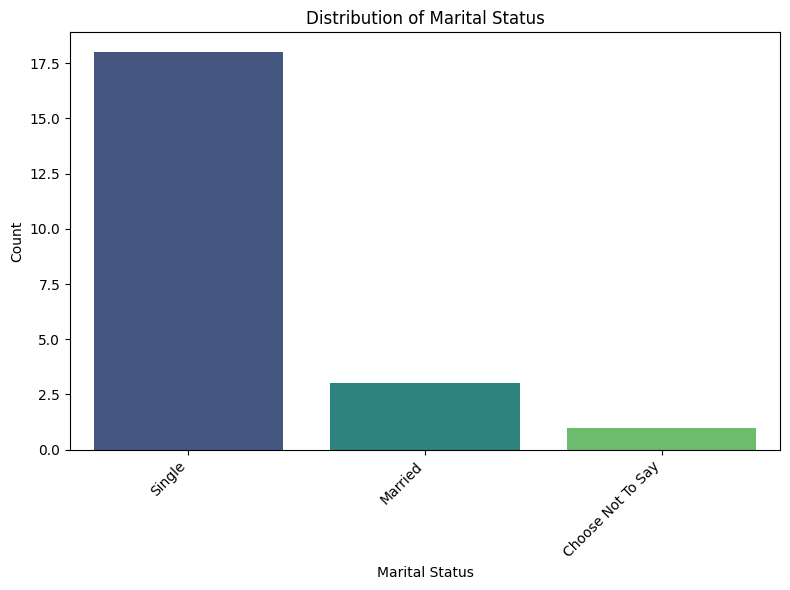

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='marital_status', data=df, palette='viridis', hue='marital_status', legend=False, order=df['marital_status'].value_counts().index)
plt.title('Distribution of Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df['residence_type'] = df['residence_type'].str.title()
print('Unique values in residence_type after standardization:')
display(df['residence_type'].value_counts())

Unique values in residence_type after standardization:


,count
residence_type,
Rural,14
Urban,8


### Visualization: Residence Type Distribution (Pie Chart)

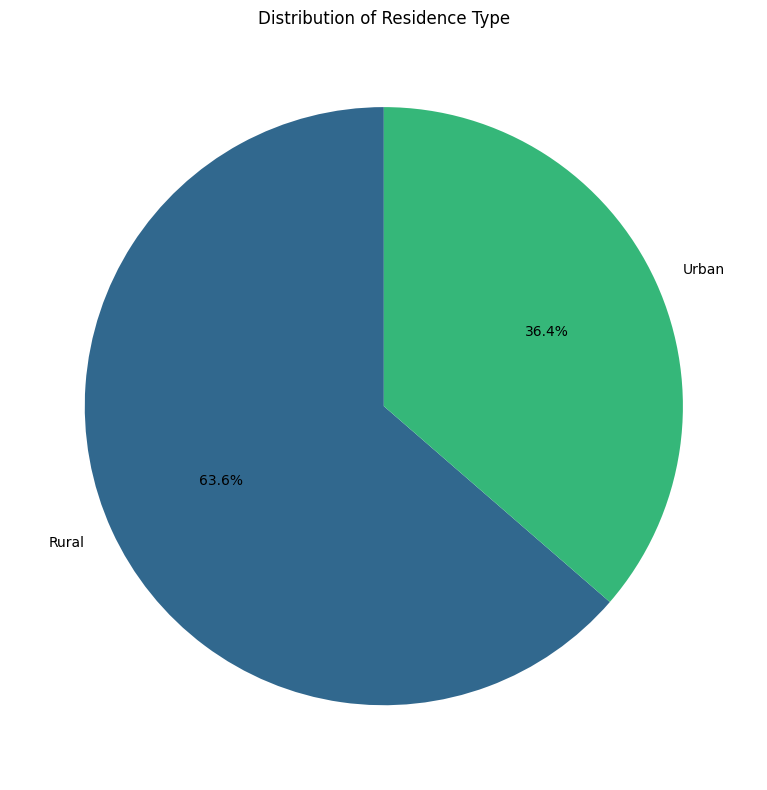

In [ ]:
plt.figure(figsize=(8, 8))
residence_counts = df['residence_type'].value_counts()
plt.pie(residence_counts, labels=residence_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(residence_counts)))
plt.title('Distribution of Residence Type')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Exploring Other Features

In [ ]:
print('Unique values in self_reported_health_status (after standardization):')
display(df['self_reported_health_status'].value_counts())

Unique values in self_reported_health_status (after standardization):


,count
self_reported_health_status,
Good,10
good,6
Excellent,3
Excellent,1
Fair,1
excellent,1


In [ ]:
df['sex'] = df['sex'].astype(str).str.title()
print('Unique values in sex after standardization:')
display(df['sex'].value_counts())

Unique values in sex after standardization:


,count
sex,
Female,22


### Visualization: Sex Distribution

### Visualization: Religion Distribution

In [ ]:
df['year_of_study'] = df['year_of_study'].astype(str).str.title()
print('Unique values in year_of_study after standardization:')
display(df['year_of_study'].value_counts())

Unique values in year_of_study after standardization:


,count
year_of_study,
4,20
6,1
,1


### Visualization: Year of Study Distribution

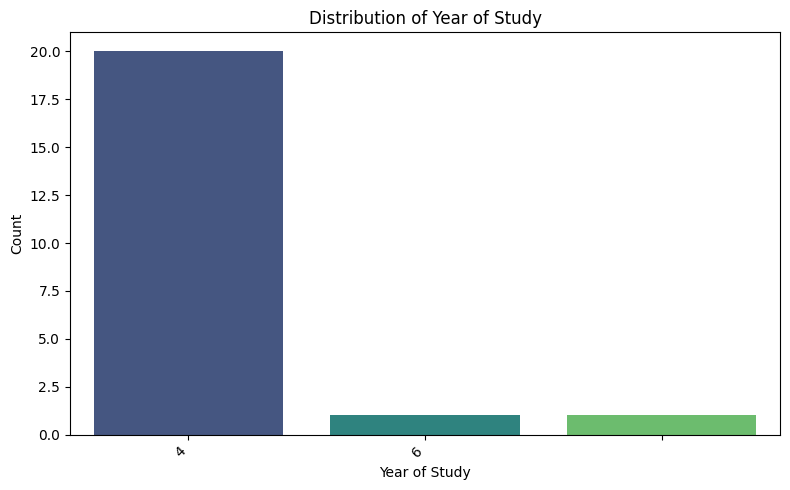

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='year_of_study', data=df, palette='viridis', hue='year_of_study', legend=False, order=df['year_of_study'].value_counts().index)
plt.title('Distribution of Year of Study')
plt.xlabel('Year of Study')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Visualization: Lifestyle Factors vs. Hours of Sleep
We will use scatter plots to explore relationships between sleep and other habits. Jitter is added to handle overlapping points since the values are discrete.

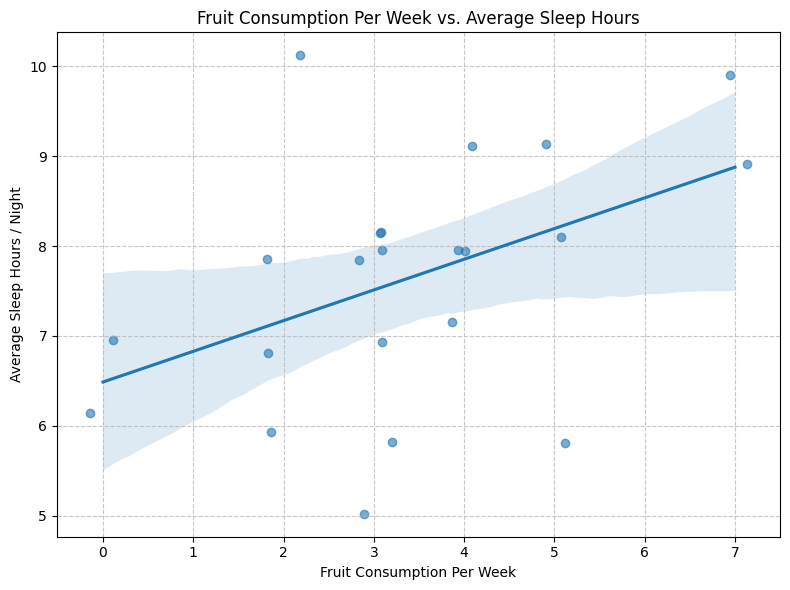

In [ ]:
plt.figure(figsize=(8, 6))
sns.regplot(x='fruit_consumption_per_week', y='average_sleep_hours_per_night', data=df, x_jitter=0.2, y_jitter=0.2, scatter_kws={'alpha':0.6})
plt.title('Fruit Consumption Per Week vs. Average Sleep Hours')
plt.xlabel('Fruit Consumption Per Week')
plt.ylabel('Average Sleep Hours / Night')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Correlation Analysis: Lifestyle vs. Sleep
We will now calculate the correlation coefficients to quantify the strength of the relationships visualized above.

Correlation Matrix:


,average_sleep_hours_per_night,fruit_consumption_per_week,daily_water_intake_glasses,physical_activity_frequency_per_week
average_sleep_hours_per_night,1.000000,0.459243,-0.123137,0.193742
fruit_consumption_per_week,0.459243,1.000000,0.309517,0.186070
daily_water_intake_glasses,-0.123137,0.309517,1.000000,0.476186
physical_activity_frequency_per_week,0.193742,0.186070,0.476186,1.000000


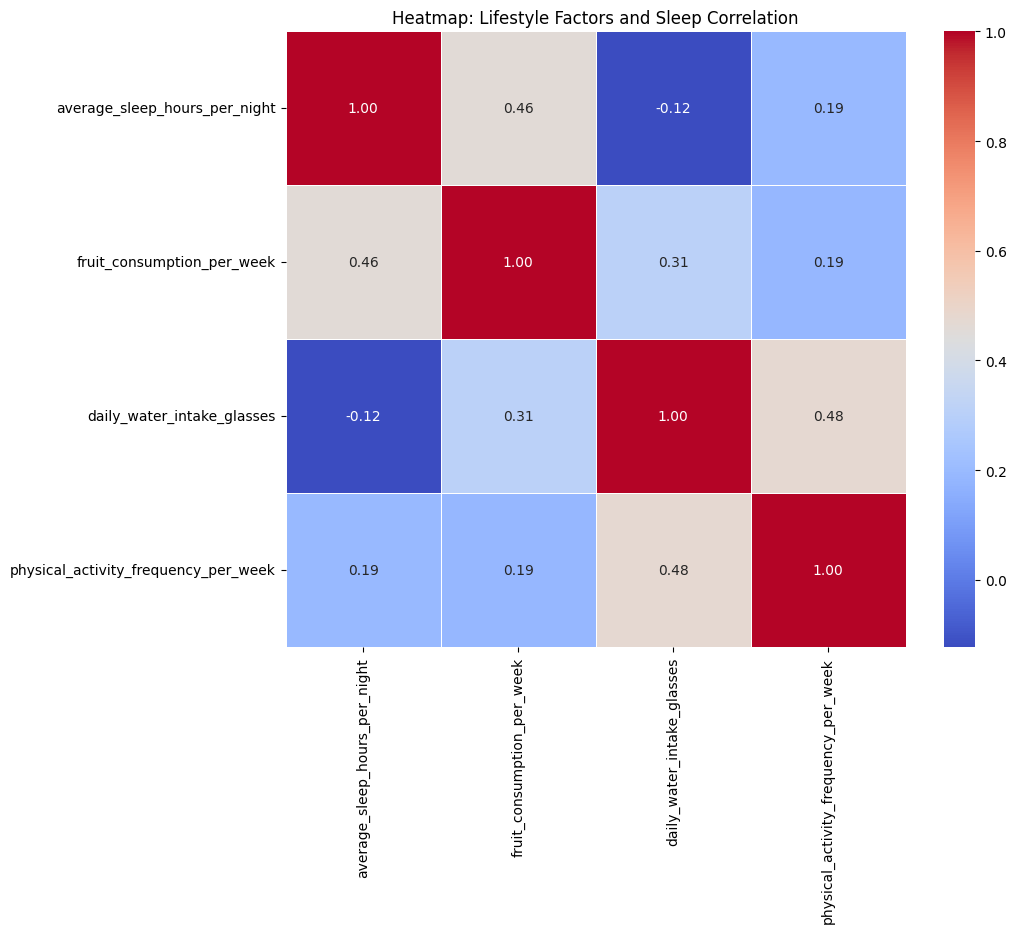

In [ ]:
selected_cols = ['average_sleep_hours_per_night', 'fruit_consumption_per_week', 'daily_water_intake_glasses', 'physical_activity_frequency_per_week']
correlation_matrix = df[selected_cols].corr()

print("Correlation Matrix:")
display(correlation_matrix)

# Visualizing the matrix with a heatmap for better readability
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap: Lifestyle Factors and Sleep Correlation')
plt.show()

### Visualization: BMI and Self-Reported Health Status
We will examine how BMI relates to how participants perceive their own health.

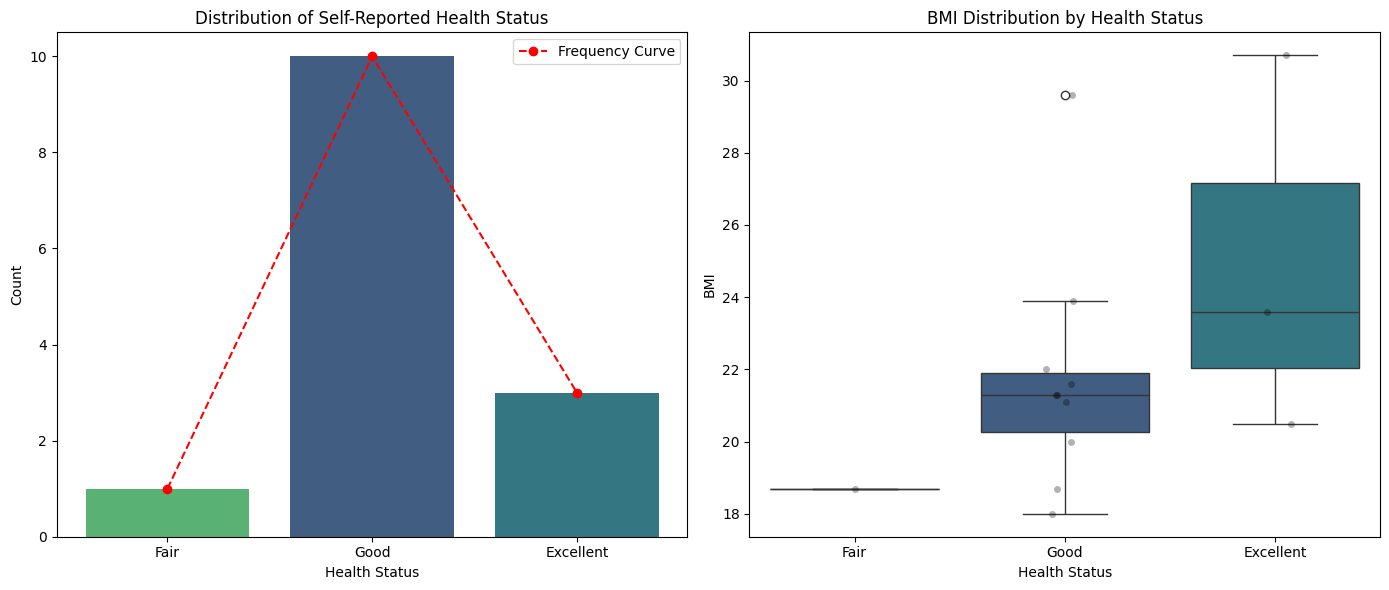

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the order for health status for better visualization
health_order = ['Fair', 'Good', 'Excellent']

plt.figure(figsize=(14, 6))

# Subplot 1: Distribution of Self-Reported Health Status (Bar Chart + Frequency Curve)
plt.subplot(1, 2, 1)
sns.countplot(x='self_reported_health_status', data=df, palette='viridis', order=health_order, hue='self_reported_health_status', legend=False)
plt.title('Distribution of Self-Reported Health Status')
plt.xlabel('Health Status')
plt.ylabel('Count')

# Get counts for the frequency curve and reindex to match the order
health_status_counts = df['self_reported_health_status'].value_counts().reindex(health_order)
plt.plot(health_status_counts.index, health_status_counts.values, color='red', marker='o', linestyle='--', label='Frequency Curve') # Add frequency curve
plt.legend()

# Subplot 2: BMI Distribution by Health Status
plt.subplot(1, 2, 2)
sns.boxplot(x='self_reported_health_status', y='bmi', data=df, palette='viridis', order=health_order, hue='self_reported_health_status', legend=False)
sns.stripplot(x='self_reported_health_status', y='bmi', data=df, color='black', alpha=0.3, order=health_order) # Adding points to see distribution
plt.title('BMI Distribution by Health Status')
plt.xlabel('Health Status')
plt.ylabel('BMI')

plt.tight_layout()
plt.show()

### Visualization: Daily Water Intake vs. BMI

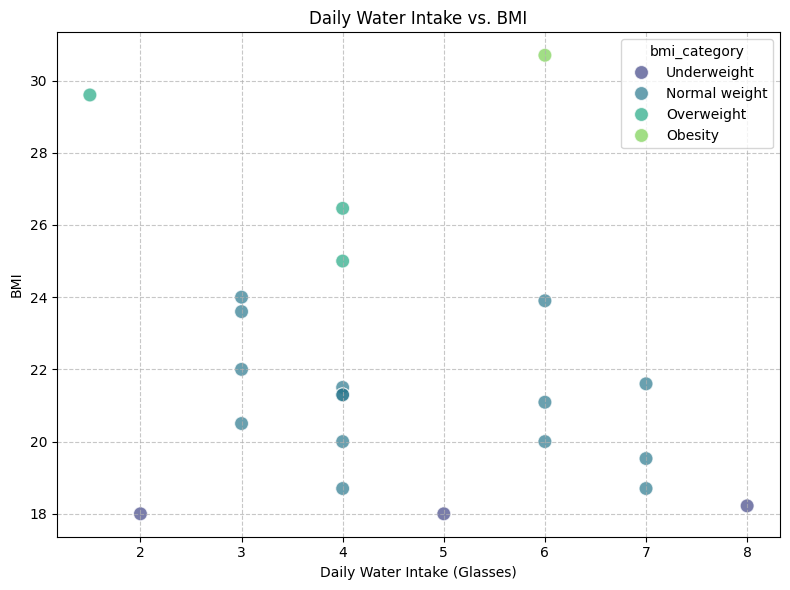

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='daily_water_intake_glasses', y='bmi', data=df, hue='bmi_category', palette='viridis', s=100, alpha=0.7)
plt.title('Daily Water Intake vs. BMI')
plt.xlabel('Daily Water Intake (Glasses)')
plt.ylabel('BMI')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

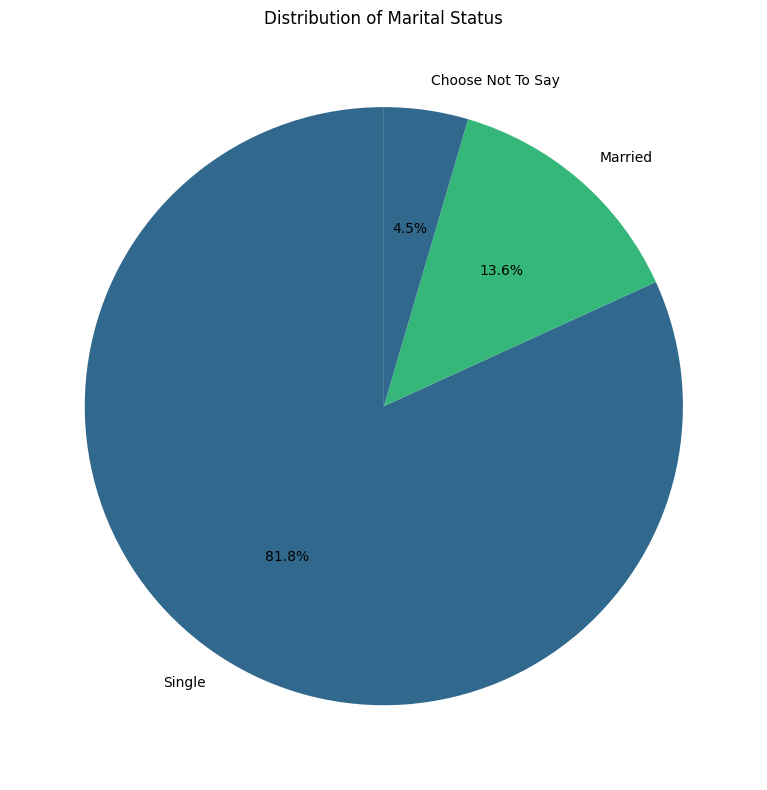

In [ ]:
plt.figure(figsize=(8, 8))
marital_status = df['marital_status'].value_counts()
plt.pie(marital_status, labels=marital_status.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(residence_counts)))
plt.title('Distribution of Marital Status')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
summary_stats = df.describe()
display(summary_stats)

,age_years,weight_kg,height_cm,waist_circumference_cm,muac_cm,bmi,meals_per_day,fruit_consumption_per_week,vegetable_consumption_per_week,sugary_drink_consumption_per_week,physical_activity_frequency_per_week,average_sleep_hours_per_night,daily_water_intake_glasses
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,22.863636,57.545455,159.345455,28.727273,16.954545,21.985909,3.136364,3.363636,6.681818,4.181818,4.636364,7.636364,4.613636
std,2.030610,13.383456,9.644575,3.149933,5.690236,3.512960,0.560226,1.787402,2.834924,2.611994,2.421048,1.328997,1.772353
min,20.000000,41.000000,150.000000,24.000000,10.000000,18.000000,2.000000,0.000000,2.000000,0.000000,0.000000,5.000000,1.500000
25%,22.000000,52.000000,153.500000,27.250000,13.000000,19.647500,3.000000,2.250000,6.000000,2.250000,3.000000,7.000000,3.250000
50%,22.000000,55.000000,158.000000,28.000000,15.500000,21.295000,3.000000,3.000000,7.000000,4.000000,5.000000,8.000000,4.000000
75%,23.750000,60.000000,161.550000,30.000000,20.000000,23.825000,3.000000,4.000000,7.000000,6.500000,7.000000,8.000000,6.000000
max,30.000000,109.000000,192.000000,38.000000,29.000000,30.700000,5.000000,7.000000,17.000000,10.000000,10.000000,10.000000,8.000000
